In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score , confusion_matrix

In [3]:
df = pd.read_csv('heart_disease_uci(1).csv')

In [4]:
df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [5]:
#cheching null values

print("Missing Values in each column::\n",df.isnull().sum())

Missing Values in each column::
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [8]:
print("Data Types are::\n",df.dtypes)

Data Types are::
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


In [9]:
pd.set_option('future.no_silent_downcasting', True)

In [10]:
mean_columns = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
mode_columns = ['fbs', 'restecg', 'exang', 'slope', 'thal']

In [11]:
for col in mean_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

In [12]:
for col in mode_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
df = df.infer_objects(copy=False)

In [14]:
print(df.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [15]:
#data integration 
df["hospital_id"] = np.random.randint(100, 105, size=len(df))


In [16]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,hospital_id
0,1,63,Male,Cleveland,typical angina,145.000000,233.0,True,lv hypertrophy,150.000000,False,2.300000,downsloping,0.000000,fixed defect,0,101
1,2,67,Male,Cleveland,asymptomatic,160.000000,286.0,False,lv hypertrophy,108.000000,True,1.500000,flat,3.000000,normal,2,104
2,3,67,Male,Cleveland,asymptomatic,120.000000,229.0,False,lv hypertrophy,129.000000,True,2.600000,flat,2.000000,reversable defect,1,102
3,4,37,Male,Cleveland,non-anginal,130.000000,250.0,False,normal,187.000000,False,3.500000,downsloping,0.000000,normal,0,104
4,5,41,Female,Cleveland,atypical angina,130.000000,204.0,False,lv hypertrophy,172.000000,False,1.400000,upsloping,0.000000,normal,0,101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.000000,333.0,True,st-t abnormality,154.000000,False,0.000000,flat,0.676375,normal,1,100
916,917,62,Male,VA Long Beach,typical angina,132.132404,139.0,False,st-t abnormality,137.545665,False,0.878788,flat,0.676375,normal,0,101
917,918,55,Male,VA Long Beach,asymptomatic,122.000000,223.0,True,st-t abnormality,100.000000,False,0.000000,flat,0.676375,fixed defect,2,104
918,919,58,Male,VA Long Beach,asymptomatic,132.132404,385.0,True,lv hypertrophy,137.545665,False,0.878788,flat,0.676375,normal,0,104


In [17]:
#merging the columns 
df1 = df[['age', 'cp', 'chol', 'thalch']]
df2 = df[['exang', 'slope', 'num']]

merged_df = pd.concat([df1, df2], axis=1)

print("Shape of Merged DataFrame:", merged_df.shape)
print("Columns:", merged_df.columns.tolist())


Shape of Merged DataFrame: (920, 7)
Columns: ['age', 'cp', 'chol', 'thalch', 'exang', 'slope', 'num']


In [18]:
#mark outliers using IQR method 

def mark_outliers(column):
    if column.dtype.kind in 'iufc':
        Q1 = column.quantile(0.25)
        Q3 = column.quantile(0.75)
        IQR = Q3 - Q1
        threshold = 1.5 * IQR


        outlier_mask = (column < Q1 - threshold) | (column > Q3 + threshold)
        return column.where(outlier_mask)
    else:
        return column

numeric_columns = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in numeric_columns:
    if col in df.columns:
        df[f'{col}_outliers'] = mark_outliers(df[col])

outlier_columns = [f'{col}_outliers' for col in numeric_columns]
outliers_df = df[outlier_columns].dropna(how='all')

print("Rows with outliers:")
print(outliers_df)


Rows with outliers:
     age_outliers  trestbps_outliers  chol_outliers  thalch_outliers  \
0             NaN                NaN            NaN              NaN   
1             NaN                NaN            NaN              NaN   
2             NaN                NaN            NaN              NaN   
3             NaN                NaN            NaN              NaN   
4             NaN                NaN            NaN              NaN   
..            ...                ...            ...              ...   
841           NaN                NaN            NaN              NaN   
854           NaN              172.0            NaN              NaN   
863           NaN                NaN            NaN              NaN   
889           NaN              180.0            NaN              NaN   
896           NaN              190.0            NaN              NaN   

     oldpeak_outliers  ca_outliers  
0                 NaN          0.0  
1                 NaN          3.0  
2   

In [19]:
#removing outliers 

def remove_outliers(df, column):
    if df[column].dtype.kind in 'iufc':
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        return df_clean 
    else:
        return df

df_clean = df
for col in numeric_columns:
    if col in df.columns:
        df_clean = remove_outliers(df_clean, col)
print(df_clean)

      id  age     sex        dataset               cp    trestbps   chol  \
166  167   52    Male      Cleveland      non-anginal  138.000000  223.0   
192  193   43    Male      Cleveland     asymptomatic  132.000000  247.0   
287  288   58    Male      Cleveland  atypical angina  125.000000  220.0   
302  303   38    Male      Cleveland      non-anginal  138.000000  175.0   
303  304   28    Male      Cleveland  atypical angina  130.000000  132.0   
..   ...  ...     ...            ...              ...         ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic  127.000000  333.0   
916  917   62    Male  VA Long Beach   typical angina  132.132404  139.0   
917  918   55    Male  VA Long Beach     asymptomatic  122.000000  223.0   
918  919   58    Male  VA Long Beach     asymptomatic  132.132404  385.0   
919  920   62    Male  VA Long Beach  atypical angina  120.000000  254.0   

       fbs           restecg      thalch  ...        ca               thal  \
166  Fals

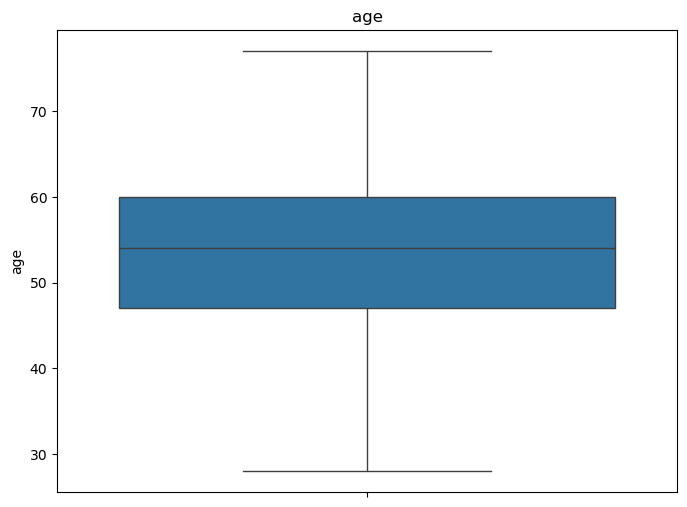

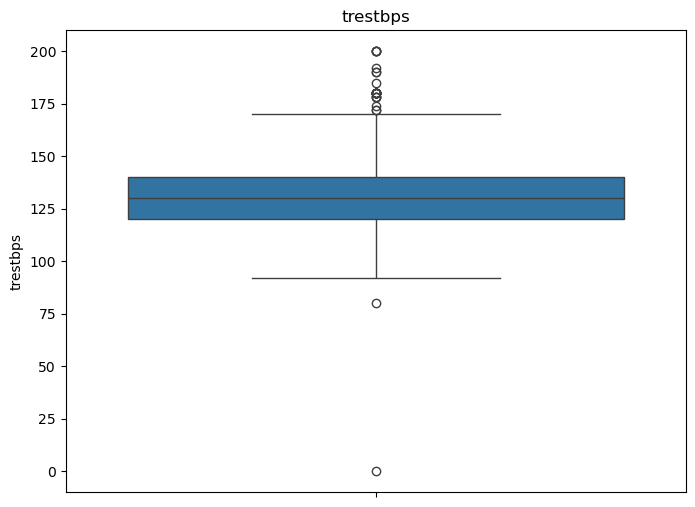

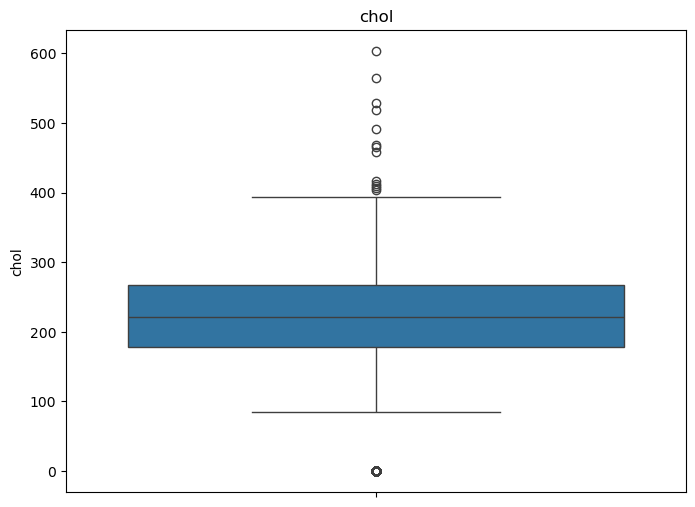

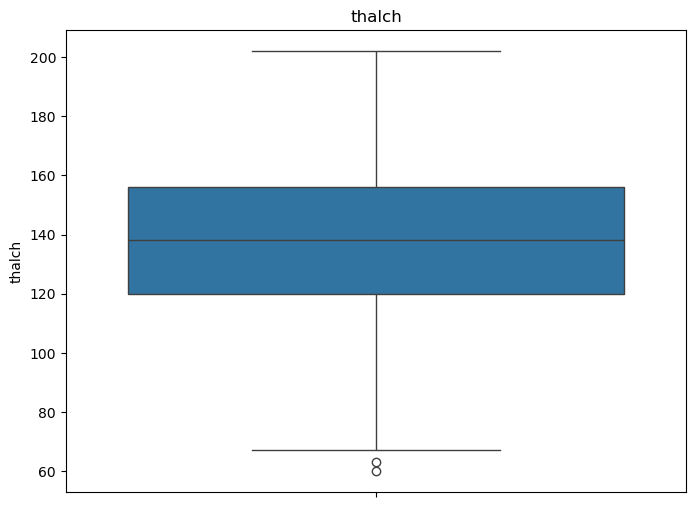

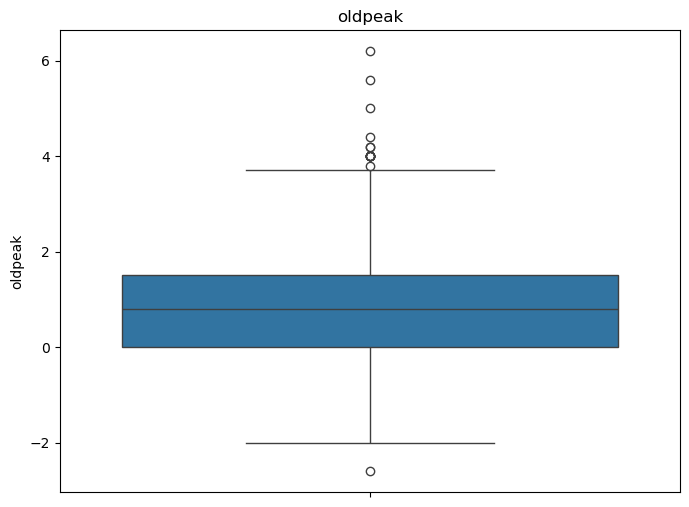

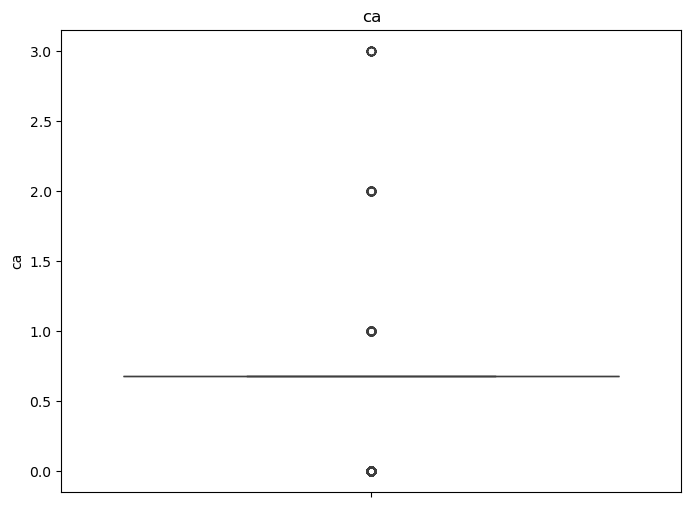

In [20]:
col_name = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in col_name:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=df[col])
    plt.title(col)
    plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

Correlation with the Target:
id                   0.273552
age                  0.339596
trestbps             0.116225
chol                -0.228238
thalch              -0.351055
oldpeak              0.421907
ca                   0.321404
hospital_id         -0.004637
age_outliers              NaN
trestbps_outliers   -0.053648
chol_outliers       -0.192885
thalch_outliers      1.000000
oldpeak_outliers     0.286228
ca_outliers          0.516216
Name: num, dtype: float64


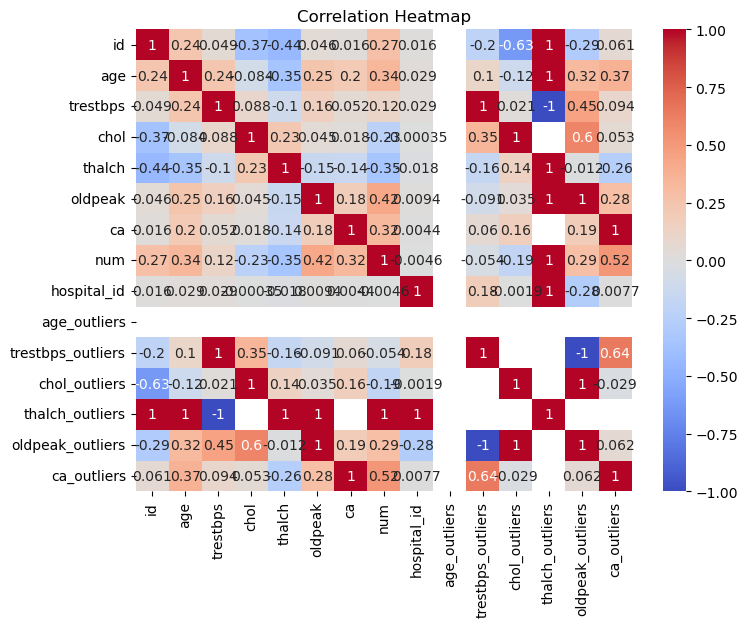

In [22]:
numeric_df = df.select_dtypes(include=np.number)
correlations = numeric_df.corr()['num'].drop('num')
print("Correlation with the Target:")
print(correlations)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
#data transformation 
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [24]:
df1 = df.copy()

label_encoder = LabelEncoder()
scaler = StandardScaler()

categorical_cols = ['sex','dataset','cp','restecg','slope','thal']
numeric_cols = ['age','trestbps','chol','thalch','oldpeak','ca']

for col in categorical_cols:
    if col in df1.columns:
        df1[col] = label_encoder.fit_transform(df1[col].astype(str))

df1[numeric_cols] = df1[numeric_cols].fillna(df1[numeric_cols].mean())
df1[numeric_cols] = scaler.fit_transform(df1[numeric_cols])

print(df1.head())

   id       age  sex  dataset  cp  trestbps      chol    fbs  restecg  \
0   1  1.007386    1        0   3  0.698041  0.311021   True        0   
1   2  1.432034    1        0   0  1.511761  0.797713  False        0   
2   3  1.432034    1        0   0 -0.658158  0.274289  False        0   
3   4 -1.752828    1        0   2 -0.115679  0.467130  False        1   
4   5 -1.328180    0        0   1 -0.115679  0.044717  False        0   

     thalch  ...        ca  thal  num  hospital_id  age_outliers  \
0  0.495698  ... -1.249371     0    0          101           NaN   
1 -1.175955  ...  4.292099     1    2          104           NaN   
2 -0.340128  ...  2.444942     2    1          102           NaN   
3  1.968345  ... -1.249371     1    0          104           NaN   
4  1.371326  ... -1.249371     1    0          101           NaN   

   trestbps_outliers  chol_outliers  thalch_outliers  oldpeak_outliers  \
0                NaN            NaN              NaN               NaN   
1   

In [26]:
#model building 

df['thal'] = df['thal'].replace({
    'fixeddefect': 'fixed_defect',
    'reversabledefect': 'reversible_defect'
})

df['cp'] = df['cp'].replace({
    'typicalangina': 'typical_angina',
    'atypicalangina': 'atypical_angina'
})

df['restecg'] = df['restecg'].replace({
    'normal': 'normal',
    'st-t abnormality': 'ST-T_wave_abnormality',
    'lv hypertrophy': 'left_ventricular_hypertrophy'
})

data_1 = df[['age','sex','cp','dataset','trestbps','chol','fbs',
             'restecg','thalch','exang','oldpeak','slope','ca','thal']].copy()
data_1['target'] = (df['num'] > 0).astype(int)
data_1['sex'] = (df['sex'] == 'Male').astype(int)
data_1['fbs'] = df['fbs'].astype(int)
data_1['exang'] = df['exang'].astype(int)

data_1.columns = [
    'age', 'sex', 'chest_pain_type', 'country',
    'resting_blood_pressure', 'cholesterol',
    'fasting_blood_sugar', 'restecg',
    'max_heart_rate_achieved',
    'exercise_induced_angina',
    'st_depression', 'st_slope_type',
    'num_major_vessels',
    'thalassemia_type',
    'target'
]

data_1.head()


,age,sex,chest_pain_type,country,resting_blood_pressure,cholesterol,fasting_blood_sugar,restecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope_type,num_major_vessels,thalassemia_type,target
0,63,1,typical angina,Cleveland,145.0,233.0,1,left_ventricular_hypertrophy,150.0,0,2.3,downsloping,0.0,fixed defect,0
1,67,1,asymptomatic,Cleveland,160.0,286.0,0,left_ventricular_hypertrophy,108.0,1,1.5,flat,3.0,normal,1
2,67,1,asymptomatic,Cleveland,120.0,229.0,0,left_ventricular_hypertrophy,129.0,1,2.6,flat,2.0,reversable defect,1
3,37,1,non-anginal,Cleveland,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0.0,normal,0
4,41,0,atypical angina,Cleveland,130.0,204.0,0,left_ventricular_hypertrophy,172.0,0,1.4,upsloping,0.0,normal,0


In [29]:
df['thal'] = df['thal'].replace({
    'fixed defect': 'fixed_defect',
    'reversable defect': 'reversible_defect'
})

df['cp'] = df['cp'].replace({
    'typical angina': 'typical_angina',
    'atypical angina': 'atypical_angina'
})

df['restecg'] = df['restecg'].replace({
    'normal': 'normal',
    'st-t abnormality': 'ST-T_wave_abnormality',
    'lv hypertrophy': 'left_ventricular_hypertrophy'
})

df['target'] = (df['num'] > 0).astype(int)

df['sex'] = (df['sex'] == 'Male').astype(int)
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

df.rename(columns={
    'cp': 'chest_pain_type',
    'dataset': 'country',
    'trestbps': 'resting_blood_pressure',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'resting_ecg_result',
    'thalch': 'max_heart_rate_achieved',
    'exang': 'exercise_induced_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope_type',
    'ca': 'num_major_vessels',
    'thal': 'thalassemia_type'
}, inplace=True)


df.head()

,id,age,sex,country,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg_result,max_heart_rate_achieved,...,thalassemia_type,num,hospital_id,age_outliers,trestbps_outliers,chol_outliers,thalch_outliers,oldpeak_outliers,ca_outliers,target
0,1,63,0,Cleveland,typical_angina,145.0,233.0,1,left_ventricular_hypertrophy,150.0,...,fixed_defect,0,101,NaN,NaN,NaN,NaN,NaN,0.0,0
1,2,67,0,Cleveland,asymptomatic,160.0,286.0,0,left_ventricular_hypertrophy,108.0,...,normal,2,104,NaN,NaN,NaN,NaN,NaN,3.0,1
2,3,67,0,Cleveland,asymptomatic,120.0,229.0,0,left_ventricular_hypertrophy,129.0,...,reversible_defect,1,102,NaN,NaN,NaN,NaN,NaN,2.0,1
3,4,37,0,Cleveland,non-anginal,130.0,250.0,0,normal,187.0,...,normal,0,104,NaN,NaN,NaN,NaN,NaN,0.0,0
4,5,41,0,Cleveland,atypical_angina,130.0,204.0,0,left_ventricular_hypertrophy,172.0,...,normal,0,101,NaN,NaN,NaN,NaN,NaN,0.0,0


In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

In [38]:
X = df.drop('target', axis=1)
y = df['target']

In [39]:
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        X[col] = label_encoder.fit_transform(X[col])

In [40]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

C:\Users\subhe\anaconda3\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['age_outliers']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,
    stratify=y   # keeps class distribution balanced
)

In [42]:
models = [
    ("LogisticRegression", LogisticRegression(random_state=42, max_iter=1000)),
    ("SVM", SVC(random_state=42, probability=True)),
    ("DecisionTreeClassifier", DecisionTreeClassifier(random_state=42)),
    ("KNeighborsClassifier", KNeighborsClassifier())
]

In [43]:
model_scores = []

for name, model in models:
    model.fit(X_train, y_train)
        
    y_pred = model.predict(X_test)

 
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    accuracy = accuracy_score(y_test, y_pred)  
    f1 = f1_score(y_test, y_pred, average='weighted')  
    precision = precision_score(y_test, y_pred, average='weighted')  
    recall = recall_score(y_test, y_pred, average='weighted')  
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None  

    model_scores.append((name, accuracy, f1, precision, recall, roc_auc))

    print(f" {name}")
    print(f" Accuracy: {accuracy:.2f}")
    print(f" F1 Score: {f1:.2f}")
    print(f" Precision: {precision:.2f}")
    print(f" Recall: {recall:.2f}")
    if roc_auc is not None:
        print(f" ROC AUC: {roc_auc:.2f}")
    print("-" * 50)

C:\Users\subhe\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 LogisticRegression
 Accuracy: 1.00
 F1 Score: 1.00
 Precision: 1.00
 Recall: 1.00
 ROC AUC: 1.00
--------------------------------------------------
 SVM
 Accuracy: 0.76
 F1 Score: 0.76
 Precision: 0.77
 Recall: 0.76
 ROC AUC: 0.78
--------------------------------------------------
 DecisionTreeClassifier
 Accuracy: 1.00
 F1 Score: 1.00
 Precision: 1.00
 Recall: 1.00
 ROC AUC: 1.00
--------------------------------------------------
 KNeighborsClassifier
 Accuracy: 0.80
 F1 Score: 0.80
 Precision: 0.80
 Recall: 0.80
 ROC AUC: 0.87
--------------------------------------------------
